# SW and SE nearest-neighbour distance model using raw DGR values

## Setup

In [ ]:
options(scipen = 999)

required_packages <- c(
  "sf",
  "dplyr",
  "tidyr",
  "purrr",
  "ggplot2",
  "patchwork",
  "readxl",
  "stringr",
  "mgcv"
)

missing_packages <- required_packages[!vapply(
  required_packages,
  requireNamespace,
  quietly = TRUE,
  FUN.VALUE = logical(1)
)]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Missing required package(s):",
      paste(missing_packages, collapse = ", "),
      "\nInstall them before rendering this Quarto document."
    ),
    call. = FALSE
  )
}

library(sf)


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE


Attachement du package : 'dplyr'

Les objets suivants sont masqués depuis 'package:stats':

    filter, lag

Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union

Le chargement a nécessité le package : nlme


Attachement du package : 'nlme'

L'objet suivant est masqué depuis 'package:dplyr':

    collapse

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.

## User Parameters

In [ ]:
cadaster_path <- "Data/shp/Cadaster_NBS_Dec2025.shp"
id_col <- "ID"

output_dir <- "Figures/Spatial_analysis"
presence_thresholds <- seq(10, 500, by = 10)
min_presence_group_n <- 10

harvest_path <- "Data/NBS - Récolte 2025.xlsx"
harvest_sheet <- "Copie base donnée"

save_dpi <- 300
plot_width <- 8.5
plot_height <- 6.0


## Helper Functions

In [ ]:
save_plot <- function(plot_obj, filename, width = plot_width, height = plot_height) {
  ggplot2::ggsave(
    filename = filename,
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    dpi = save_dpi,
    bg = "white"
  )
}

theme_spatial <- function() {
  theme_minimal(base_size = 11) +
    theme(
      panel.grid.major = element_line(colour = "grey88", linewidth = 0.25),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      axis.title = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(size = 10),
      plot.caption = element_text(size = 8, colour = "grey35")
    )
}

guess_utm_epsg <- function(sf_obj) {
  centroid_wgs84 <- st_as_sfc(st_bbox(sf_obj)) |>
    st_transform(4326) |>
    st_centroid()

  centroid_xy <- st_coordinates(centroid_wgs84)
  lon <- centroid_xy[1, "X"]
  lat <- centroid_xy[1, "Y"]
  zone <- floor((lon + 180) / 6) + 1
  if (lat >= 0) 32600 + zone else 32700 + zone
}

prepare_plot_geometry <- function(cadaster_path, id_col) {
  cadaster_sf <- st_read(cadaster_path, quiet = TRUE) |>
    st_make_valid()

  if (!id_col %in% names(cadaster_sf)) {
    stop(
      paste("The plot identifier column was not found in the shapefile:", id_col),
      call. = FALSE
    )
  }

  original_crs <- st_crs(cadaster_sf)
  if (is.na(original_crs)) {
    stop("The input shapefile has no CRS defined.", call. = FALSE)
  }

  original_crs_label <- original_crs$input
  transformed_crs_label <- original_crs_label

  if (isTRUE(st_is_longlat(cadaster_sf))) {
    utm_epsg <- guess_utm_epsg(cadaster_sf)
    cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
    transformed_crs_label <- paste0("EPSG:", utm_epsg)
  }

  centroid_points <- st_point_on_surface(cadaster_sf)
  centroid_coords <- st_coordinates(centroid_points)

  cadaster_sf <- cadaster_sf |>
    transmute(
      plot_id = as.character(.data[[id_col]]),
      x = centroid_coords[, "X"],
      y = centroid_coords[, "Y"]
    )

  list(
    data = cadaster_sf,
    metadata = list(
      original_crs = original_crs_label,
      analysis_crs = transformed_crs_label
    )
  )
}

prepare_raw_dgr <- function(harvest_path, harvest_sheet) {
  readxl::read_excel(harvest_path, sheet = harvest_sheet) |>
    mutate(
      FarmID = as.numeric(FarmID),
      ModuleNumber = as.numeric(ModuleNumber),
      Harvested_Weight = as.numeric(Harvested_Weight),
      CultureDuration_days = as.numeric(CultureDuration_days),
      LinesCount = as.numeric(LinesCount)
    ) |>
    filter(
      CultureMode == "Cordes",
      !is.na(FarmID),
      !is.na(ModuleNumber),
      !is.na(Harvested_Weight),
      !is.na(CultureDuration_days),
      CultureDuration_days > 0,
      !is.na(LinesCount),
      LinesCount == 100,
      Harvested_Weight > 1000
    ) |>
    mutate(
      FarmID = stringr::str_pad(as.integer(FarmID), width = 3, pad = "0"),
      ModuleNumber = as.integer(ModuleNumber),
      Module_ID = paste0(FarmID, "_", ModuleNumber),
      DGR = (log(Harvested_Weight / 700) / CultureDuration_days) * 100
    ) |>
    select(Module_ID, DGR)
}

build_sw_se_pairs <- function(plot_sf) {
  plot_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, x, y)

  tidyr::expand_grid(
    focal_index = seq_len(nrow(plot_tbl)),
    neighbour_index = seq_len(nrow(plot_tbl))
  ) |>
    filter(focal_index != neighbour_index) |>
    transmute(
      plot_id = plot_tbl$plot_id[focal_index],
      dx = plot_tbl$x[neighbour_index] - plot_tbl$x[focal_index],
      dy = plot_tbl$y[neighbour_index] - plot_tbl$y[focal_index]
    ) |>
    mutate(
      distance_m = sqrt(dx^2 + dy^2),
      direction = case_when(
        dx < 0 & dy < 0 ~ "SW",
        dx > 0 & dy < 0 ~ "SE",
        TRUE ~ NA_character_
      )
    ) |>
    filter(!is.na(direction), distance_m > 0)
}

compute_presence_combo_data <- function(pair_tbl, raw_joined, threshold_m) {
  threshold_summary <- pair_tbl |>
    filter(distance_m <= threshold_m) |>
    group_by(plot_id, direction) |>
    summarise(
      present = as.integer(dplyr::n() > 0),
      .groups = "drop"
    ) |>
    pivot_wider(
      names_from = direction,
      values_from = present,
      values_fill = 0,
      names_prefix = "present_"
    )

  for (nm in c("present_SW", "present_SE")) {
    if (!nm %in% names(threshold_summary)) {
      threshold_summary[[nm]] <- 0L
    }
  }

  raw_joined |>
    left_join(
      threshold_summary |>
        select(plot_id, present_SW, present_SE),
      by = "plot_id"
    ) |>
    mutate(
      present_SW = ifelse(is.na(present_SW), 0L, present_SW),
      present_SE = ifelse(is.na(present_SE), 0L, present_SE),
      combo = case_when(
        present_SW == 0 & present_SE == 0 ~ "Neither",
        present_SW == 1 & present_SE == 0 ~ "SW only",
        present_SW == 0 & present_SE == 1 ~ "SE only",
        TRUE ~ "SW + SE"
      ),
      combo = factor(combo, levels = c("Neither", "SW only", "SE only", "SW + SE"))
    )
}

compute_first_valid_threshold <- function(pair_tbl, raw_joined, thresholds, min_group_n) {
  threshold_counts <- purrr::map_dfr(thresholds, function(threshold_m) {
    dat <- compute_presence_combo_data(pair_tbl, raw_joined, threshold_m)

    tibble(
      distance_threshold_m = threshold_m,
      sw0 = sum(dat$present_SW == 0),
      sw1 = sum(dat$present_SW == 1),
      se0 = sum(dat$present_SE == 0),
      se1 = sum(dat$present_SE == 1)
    )
  })

  threshold_counts |>
    filter(pmin(sw0, sw1, se0, se1) >= min_group_n) |>
    arrange(distance_threshold_m) |>
    slice(1)
}

compute_closest_distances <- function(pair_tbl) {
  pair_tbl |>
    group_by(plot_id, direction) |>
    summarise(
      closest_distance_m = min(distance_m, na.rm = TRUE),
      .groups = "drop"
    ) |>
    pivot_wider(
      names_from = direction,
      values_from = closest_distance_m,
      names_prefix = "closest_"
    )
}

extract_gam_parametric <- function(gam_fit) {
  ptab <- summary(gam_fit)$p.table
  tibble(
    term = rownames(ptab),
    estimate = ptab[, "Estimate"],
    std.error = ptab[, "Std. Error"],
    statistic = ptab[, "t value"],
    p.value = ptab[, "Pr(>|t|)"],
    conf.low = estimate - 1.96 * std.error,
    conf.high = estimate + 1.96 * std.error
  )
}

fixed_effect_prediction <- function(newdata, coefficient_tbl, vcov_matrix) {
  intercept <- coefficient_tbl$estimate[coefficient_tbl$term == "(Intercept)"]
  beta_sw <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SW"]
  beta_se <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SE"]

  X <- cbind(
    1,
    newdata$log_closest_SW,
    newdata$log_closest_SE
  )

  beta <- c(intercept, beta_sw, beta_se)
  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% vcov_matrix %*% t(X)))

  tibble(
    fit = fit,
    se_fit = se,
    lwr = fit - 1.96 * se,
    upr = fit + 1.96 * se
  )
}

write_interpretation <- function(
  output_file,
  first_valid_threshold,
  combo_summary,
  coefficient_tbl,
  model_summary_tbl,
  n_rows,
  n_modules
) {
  intercept <- coefficient_tbl$estimate[coefficient_tbl$term == "(Intercept)"]
  beta_sw <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SW"]
  beta_se <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SE"]
  sw_p <- coefficient_tbl$p.value[coefficient_tbl$term == "log_closest_SW"]
  se_p <- coefficient_tbl$p.value[coefficient_tbl$term == "log_closest_SE"]

  combo_means <- combo_summary$mean_DGR
  names(combo_means) <- combo_summary$combo

  interpretation_lines <- c(
    "# Spatial analysis interpretation",
    "",
    "## Question tested",
    paste(
      "The analysis was simplified to use raw DGR values instead of module-average DGR.",
      "For each raw DGR record, the plot geometry of its module was used to compute the",
      "distance to the closest cultivated neighbour toward the SW and toward the SE."
    ),
    "",
    "## Presence plot kept from the earlier test",
    sprintf(
      paste(
        "At %d m, the combination plot still shows the same overall pattern:",
        "the highest mean raw DGR occurs when neither SW nor SE neighbours are present (%.2f),",
        "intermediate values occur for `SW only` (%.2f) and `SE only` (%.2f),",
        "and the lowest mean raw DGR occurs when both SW and SE neighbours are present (%.2f)."
      ),
      first_valid_threshold,
      combo_means["Neither"],
      combo_means["SW only"],
      combo_means["SE only"],
      combo_means["SW + SE"]
    ),
    "",
    "## Final model using closest-neighbour distances",
    sprintf(
      paste(
        "The final model was fitted on %d raw DGR observations from %d modules",
        "that had both closest-neighbour distances defined."
      ),
      n_rows,
      n_modules
    ),
    paste(
      "Because raw DGR contains repeated observations for the same module, the model",
      "uses a module-level random effect and log-transformed neighbour distances."
    ),
    sprintf(
      "`DGR_hat = %.3f + %.3f * log(SW_distance_m) %.3f * log(SE_distance_m)`",
      intercept,
      beta_sw,
      beta_se
    ),
    sprintf(
      paste(
        "At the population level, the SW coefficient is positive (%.3f, p = %.3g),",
        "meaning that larger distance to the closest SW neighbour is associated",
        "with higher DGR."
      ),
      beta_sw,
      sw_p
    ),
    sprintf(
      paste(
        "The SE coefficient is negative (%.3f, p = %.3g), meaning that larger distance",
        "to the closest SE neighbour is associated with lower DGR."
      ),
      beta_se,
      se_p
    ),
    sprintf(
      paste(
        "The model explains %.1f%% of the raw DGR variation in adjusted R2 terms,",
        "with %.1f%% deviance explained overall."
      ),
      100 * model_summary_tbl$adj_r_squared[1],
      100 * model_summary_tbl$deviance_explained[1]
    ),
    "",
    "## Simple interpretation",
    paste(
      "Using raw DGR values increases the number of observations and keeps the same",
      "main message: the SW and SE directions do not behave the same way."
    ),
    paste(
      "In this model, moving farther from the closest SW neighbour is associated",
      "with a slight increase in DGR, whereas moving farther from the closest SE",
      "neighbour is associated with a decrease in DGR."
    ),
    paste(
      "So there is no single rule such as 'greater neighbour distance always improves DGR'.",
      "Instead, the relationship depends on direction."
    ),
    "",
    "## Plot support",
    paste(
      "- Presence-combination plot:",
      "[sw_se_presence_combinations_first_valid_threshold.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/sw_se_presence_combinations_first_valid_threshold.png:1>)"
    ),
    paste(
      "- Modelled effect of closest SW and SE distance:",
      "[closest_sw_se_distance_effects.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/closest_sw_se_distance_effects.png:1>)"
    ),
    paste(
      "- Predicted DGR surface from the final model:",
      "[closest_sw_se_predicted_dgr_surface.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/closest_sw_se_predicted_dgr_surface.png:1>)"
    ),
    "",
    "## Caution",
    paste(
      "This remains an exploratory spatial model. The directional distance terms may",
      "reflect competition or hydrodynamic sheltering, but they may also be proxies",
      "for larger environmental gradients."
    )
  )

  writeLines(interpretation_lines, con = output_file)
}


## Load Geometry And Raw DGR

In [ ]:
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

plot_prep <- prepare_plot_geometry(
  cadaster_path = cadaster_path,
  id_col = id_col
)


Original CRS: WGS 84 / UTM zone 39S 

Analysis CRS: WGS 84 / UTM zone 39S 

Raw DGR rows joined to mapped modules: 4588 

Mapped modules represented: 683 

## SW/SE Pair Table

In [ ]:
pair_tbl <- build_sw_se_pairs(plot_sf)


## Keep The Combination Plot

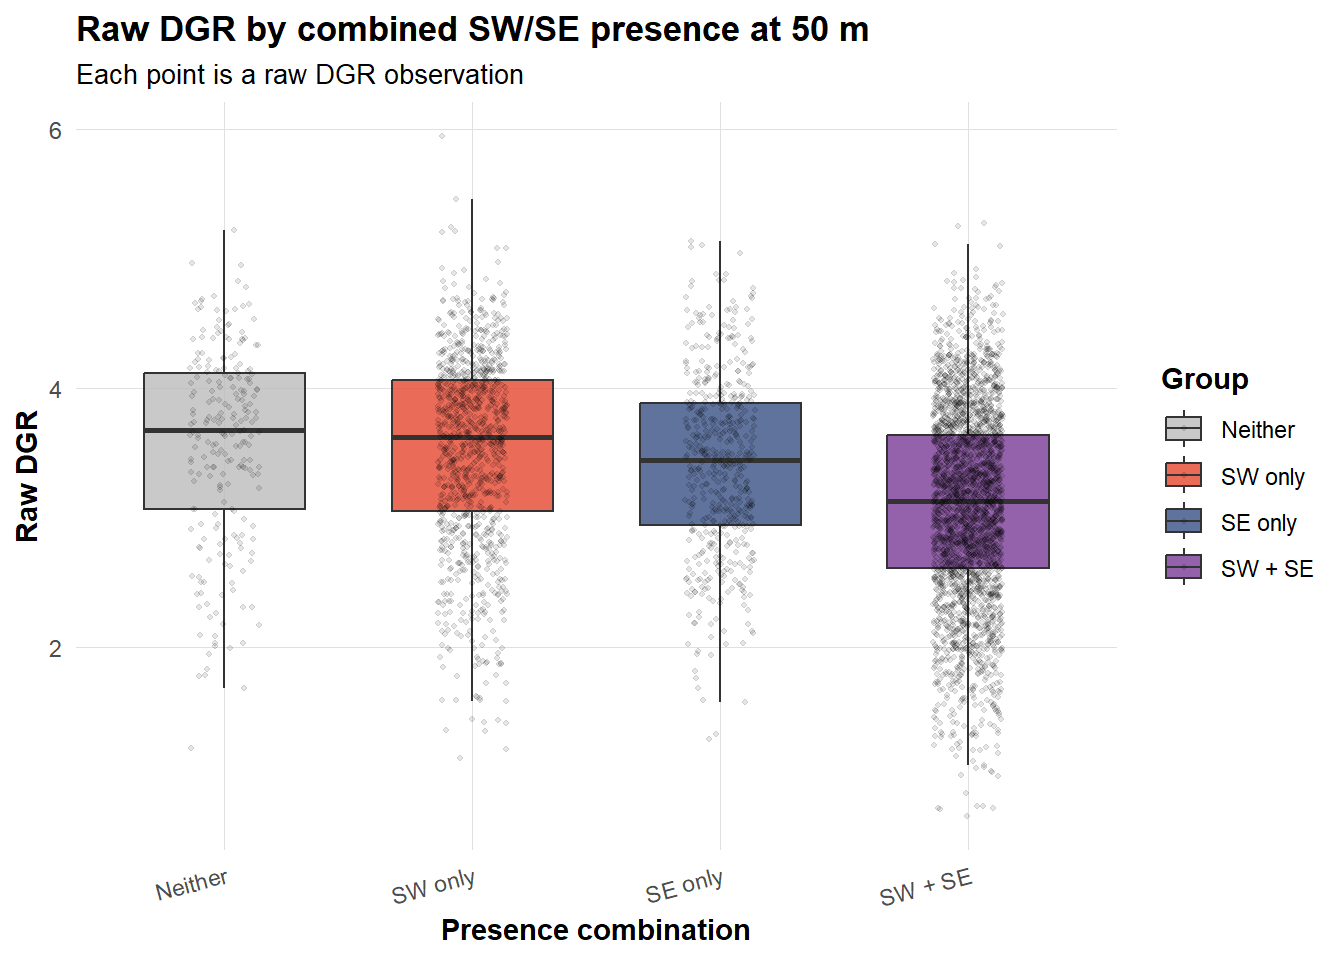

In [ ]:
first_valid_threshold_row <- compute_first_valid_threshold(
  pair_tbl = pair_tbl,
  raw_joined = raw_joined,
  thresholds = presence_thresholds,
  min_group_n = min_presence_group_n
)

first_valid_threshold <- first_valid_threshold_row$distance_threshold_m[1]

combo_data <- compute_presence_combo_data(
  pair_tbl = pair_tbl,
  raw_joined = raw_joined,
  threshold_m = first_valid_threshold
)

combo_summary <- combo_data |>
  group_by(combo) |>
  summarise(
    n = dplyr::n(),
    mean_DGR = mean(DGR, na.rm = TRUE),
    .groups = "drop"
  )

combo_plot <- ggplot(
  combo_data,
  aes(x = combo, y = DGR, fill = combo)
) +
  geom_boxplot(alpha = 0.82, outlier.shape = NA, width = 0.65) +
  geom_jitter(
    width = 0.14,
    alpha = 0.10,
    size = 0.7,
    colour = "black"
  ) +
  scale_fill_manual(
    values = c(
      "Neither" = "#BDBDBD",
      "SW only" = "#E64B35",
      "SE only" = "#3C5488",
      "SW + SE" = "#7B3F98"
    ),
    drop = FALSE
  ) +
  labs(
    title = paste0("Raw DGR by combined SW/SE presence at ", first_valid_threshold, " m"),
    subtitle = "Each point is a raw DGR observation",
    x = "Presence combination",
    y = "Raw DGR",
    fill = "Group"
  ) +
  theme_spatial() +
  theme(axis.text.x = element_text(angle = 15, hjust = 1))

save_plot(
  combo_plot,
  file.path(output_dir, "sw_se_presence_combinations_first_valid_threshold.png"),
  width = 9.5,
  height = 6.5
)

combo_plot


## Closest SW And SE Distances For Each Module

In [ ]:
closest_distance_tbl <- compute_closest_distances(pair_tbl) |>
  rename(
    plot_id = plot_id,
    closest_SW_distance_m = closest_SW,
    closest_SE_distance_m = closest_SE
  )

raw_model_data <- raw_joined |>
  left_join(closest_distance_tbl, by = "plot_id") |>
  filter(
    !is.na(closest_SW_distance_m),
    !is.na(closest_SE_distance_m)
  ) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m),
    plot_id = as.factor(plot_id)
  )

utils::write.csv(
  raw_model_data |>
    select(plot_id, DGR, closest_SW_distance_m, closest_SE_distance_m, log_closest_SW, log_closest_SE),
  file.path(output_dir, "closest_sw_se_distance_data.csv"),
  row.names = FALSE
)

cat("Raw observations used in the final model:", nrow(raw_model_data), "\n")


Raw observations used in the final model: 3803 

Modules represented in the final model: 566 

## Final Raw-Value Model

In [ ]:
distance_model <- mgcv::gam(
  DGR ~ log_closest_SW + log_closest_SE + s(plot_id, bs = "re"),
  data = raw_model_data,
  method = "REML"
)

coefficient_tbl <- extract_gam_parametric(distance_model)
fit_summary <- summary(distance_model)

model_summary_tbl <- tibble(
  n_rows = nrow(raw_model_data),
  n_modules = dplyr::n_distinct(raw_model_data$plot_id),
  adj_r_squared = fit_summary$r.sq,
  deviance_explained = fit_summary$dev.expl,
  scale_estimate = fit_summary$scale,
  AIC = AIC(distance_model)
)

utils::write.csv(
  coefficient_tbl,
  file.path(output_dir, "closest_sw_se_log_linear_model_coefficients.csv"),
  row.names = FALSE
)

utils::write.csv(
  model_summary_tbl,
  file.path(output_dir, "closest_sw_se_log_linear_model_summary.csv"),
  row.names = FALSE
)

coefficient_tbl


# A tibble: 3 × 7
  term           estimate std.error statistic  p.value conf.low conf.high
  <chr>             <dbl>     <dbl>     <dbl>    <dbl>    <dbl>     <dbl>
1 (Intercept)       3.24     0.270      12.0  1.24e-32    2.71     3.77  
2 log_closest_SW    0.165    0.0289      5.69 1.37e- 8    0.108    0.221 
3 log_closest_SE   -0.163    0.0672     -2.43 1.50e- 2   -0.295   -0.0317

# A tibble: 1 × 6
  n_rows n_modules adj_r_squared deviance_explained scale_estimate   AIC
   <int>     <int>         <dbl>              <dbl>          <dbl> <dbl>
1   3803       566         0.228              0.301          0.430 7927.

## Plots For The Final Model

ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

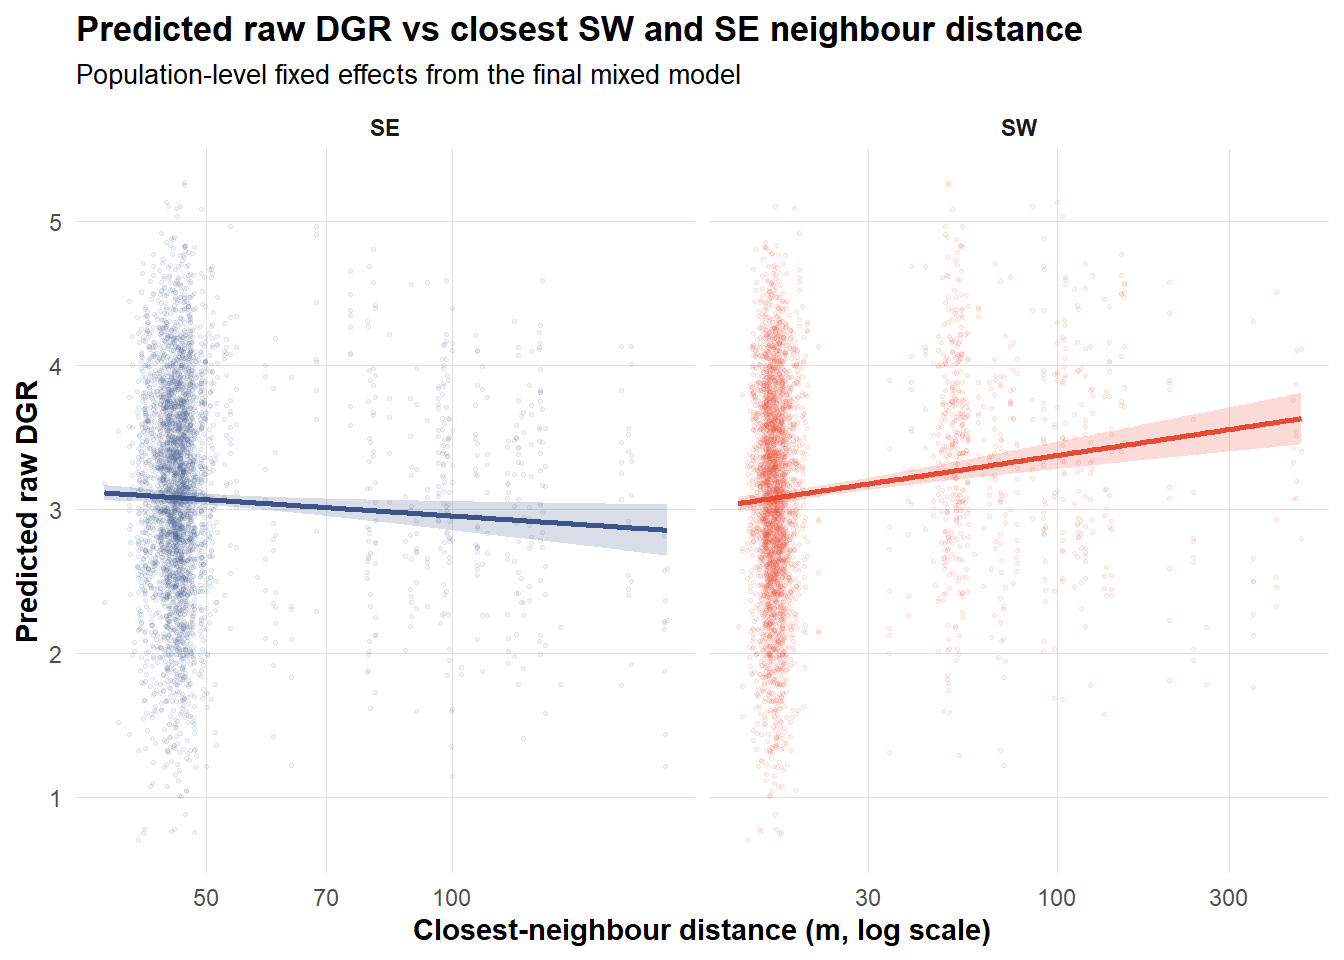

ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

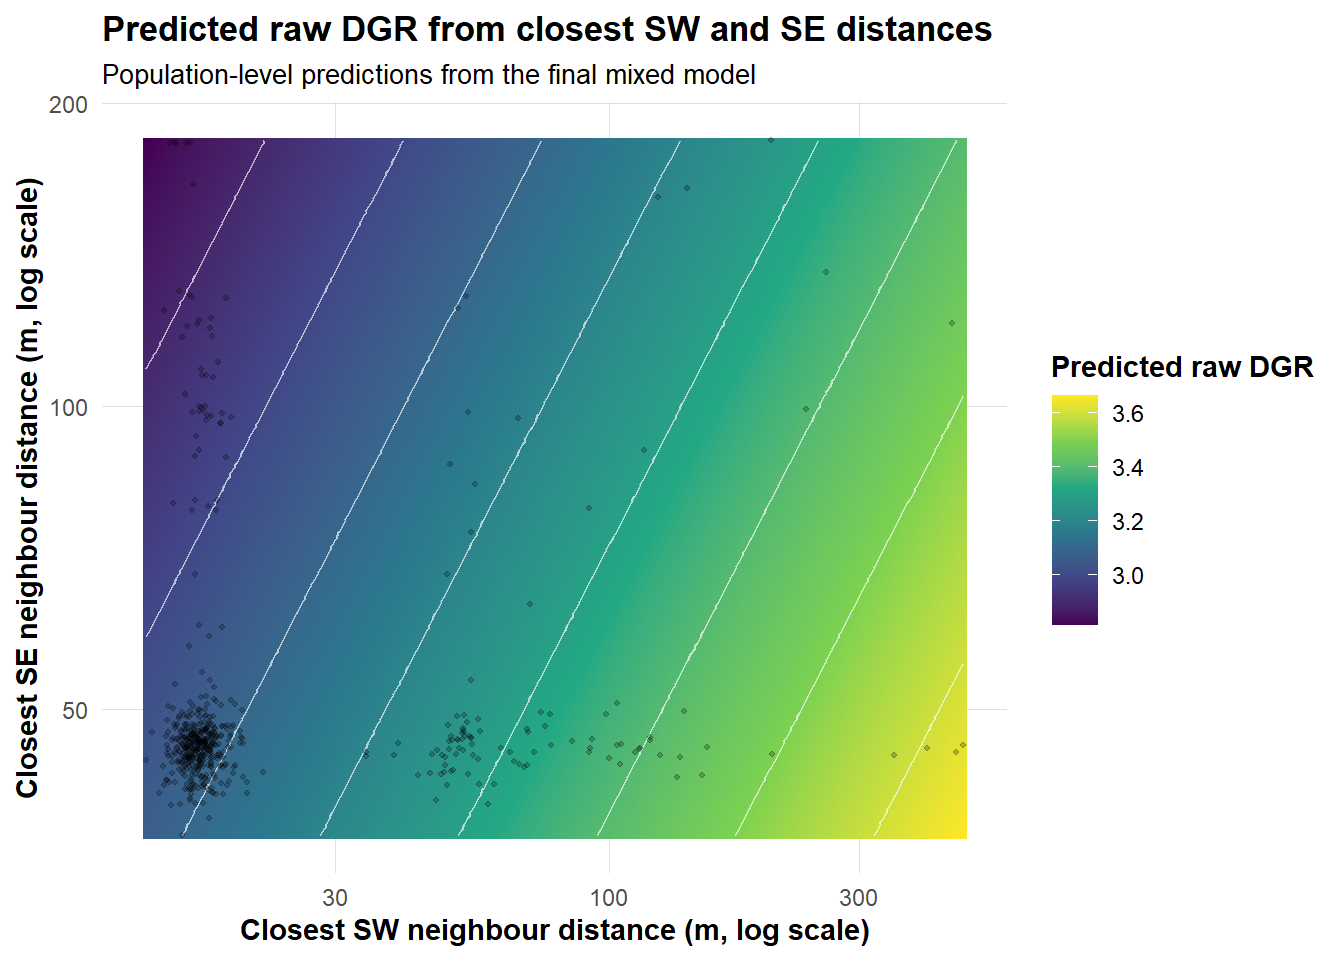

ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

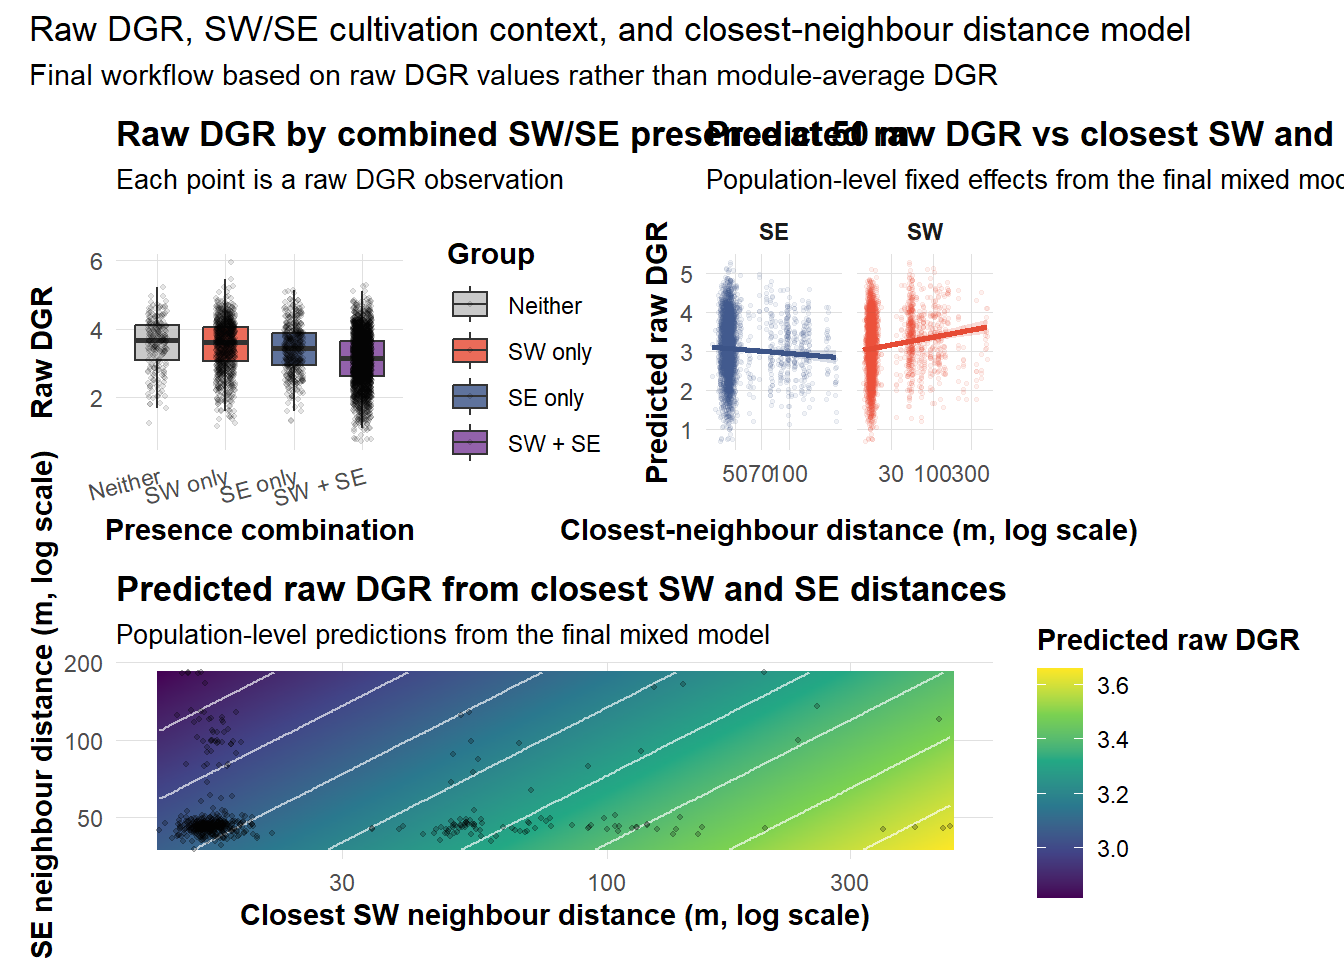

In [ ]:
param_vcov <- vcov(distance_model)[c("(Intercept)", "log_closest_SW", "log_closest_SE"), c("(Intercept)", "log_closest_SW", "log_closest_SE")]

median_sw <- median(raw_model_data$closest_SW_distance_m, na.rm = TRUE)
median_se <- median(raw_model_data$closest_SE_distance_m, na.rm = TRUE)

sw_effect_grid <- data.frame(
  closest_SW_distance_m = exp(seq(
    log(min(raw_model_data$closest_SW_distance_m)),
    log(max(raw_model_data$closest_SW_distance_m)),
    length.out = 200
  )),
  closest_SE_distance_m = median_se
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  ) |>
  mutate(direction = "SW", distance_m = closest_SW_distance_m)

sw_effect_grid <- bind_cols(
  sw_effect_grid,
  fixed_effect_prediction(
    newdata = sw_effect_grid,
    coefficient_tbl = coefficient_tbl,
    vcov_matrix = param_vcov
  )
)

se_effect_grid <- data.frame(
  closest_SW_distance_m = median_sw,
  closest_SE_distance_m = exp(seq(
    log(min(raw_model_data$closest_SE_distance_m)),
    log(max(raw_model_data$closest_SE_distance_m)),
    length.out = 200
  ))
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  ) |>
  mutate(direction = "SE", distance_m = closest_SE_distance_m)

se_effect_grid <- bind_cols(
  se_effect_grid,
  fixed_effect_prediction(
    newdata = se_effect_grid,
    coefficient_tbl = coefficient_tbl,
    vcov_matrix = param_vcov
  )
)

effect_grid <- bind_rows(sw_effect_grid, se_effect_grid)

effect_point_data <- bind_rows(
  raw_model_data |>
    transmute(direction = "SW", distance_m = closest_SW_distance_m, DGR = DGR),
  raw_model_data |>
    transmute(direction = "SE", distance_m = closest_SE_distance_m, DGR = DGR)
)

distance_effect_plot <- ggplot() +
  geom_point(
    data = effect_point_data,
    aes(x = distance_m, y = DGR, colour = direction),
    alpha = 0.08,
    size = 0.6
  ) +
  geom_ribbon(
    data = effect_grid,
    aes(x = distance_m, ymin = lwr, ymax = upr, fill = direction),
    alpha = 0.20,
    colour = NA
  ) +
  geom_line(
    data = effect_grid,
    aes(x = distance_m, y = fit, colour = direction),
    linewidth = 1.0
  ) +
  facet_wrap(~ direction, scales = "free_x") +
  scale_x_log10() +
  scale_colour_manual(values = c(SW = "#E64B35", SE = "#3C5488"), drop = FALSE) +
  scale_fill_manual(values = c(SW = "#E64B35", SE = "#3C5488"), drop = FALSE) +
  labs(
    title = "Predicted raw DGR vs closest SW and SE neighbour distance",
    subtitle = "Population-level fixed effects from the final mixed model",
    x = "Closest-neighbour distance (m, log scale)",
    y = "Predicted raw DGR",
    colour = "Direction",
    fill = "Direction"
  ) +
  theme_spatial() +
  theme(legend.position = "none")

save_plot(
  distance_effect_plot,
  file.path(output_dir, "closest_sw_se_distance_effects.png"),
  width = 10.5,
  height = 6.5
)

surface_grid <- expand_grid(
  closest_SW_distance_m = exp(seq(
    log(min(raw_model_data$closest_SW_distance_m)),
    log(max(raw_model_data$closest_SW_distance_m)),
    length.out = 120
  )),
  closest_SE_distance_m = exp(seq(
    log(min(raw_model_data$closest_SE_distance_m)),
    log(max(raw_model_data$closest_SE_distance_m)),
    length.out = 120
  ))
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  )

surface_grid <- bind_cols(
  surface_grid,
  fixed_effect_prediction(
    newdata = surface_grid,
    coefficient_tbl = coefficient_tbl,
    vcov_matrix = param_vcov
  )
)

utils::write.csv(
  surface_grid |>
    select(closest_SW_distance_m, closest_SE_distance_m, fit, lwr, upr),
  file.path(output_dir, "closest_sw_se_prediction_grid.csv"),
  row.names = FALSE
)

surface_plot <- ggplot(
  surface_grid,
  aes(x = closest_SW_distance_m, y = closest_SE_distance_m, fill = fit)
) +
  geom_raster(interpolate = TRUE) +
  geom_contour(
    aes(z = fit),
    colour = "white",
    alpha = 0.65
  ) +
  geom_point(
    data = raw_model_data |>
      distinct(plot_id, closest_SW_distance_m, closest_SE_distance_m),
    aes(x = closest_SW_distance_m, y = closest_SE_distance_m),
    inherit.aes = FALSE,
    alpha = 0.22,
    size = 0.7,
    colour = "black"
  ) +
  scale_x_log10() +
  scale_y_log10() +
  scale_fill_viridis_c(option = "D", name = "Predicted raw DGR") +
  labs(
    title = "Predicted raw DGR from closest SW and SE distances",
    subtitle = "Population-level predictions from the final mixed model",
    x = "Closest SW neighbour distance (m, log scale)",
    y = "Closest SE neighbour distance (m, log scale)"
  ) +
  theme_spatial()

save_plot(
  surface_plot,
  file.path(output_dir, "closest_sw_se_predicted_dgr_surface.png"),
  width = 8.8,
  height = 7.2
)


## Update Interpretation File

In [ ]:
write_interpretation(
  output_file = file.path(output_dir, "spatial_analysis_interpretation.md"),
  first_valid_threshold = first_valid_threshold,
  combo_summary = combo_summary,
  coefficient_tbl = coefficient_tbl,
  model_summary_tbl = model_summary_tbl,
  n_rows = nrow(raw_model_data),
  n_modules = dplyr::n_distinct(raw_model_data$plot_id)
)


## Console Summary

In [ ]:
intercept <- coefficient_tbl$estimate[coefficient_tbl$term == "(Intercept)"]
beta_sw <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SW"]
beta_se <- coefficient_tbl$estimate[coefficient_tbl$term == "log_closest_SE"]

cat("\nRaw-value SW/SE closest-neighbour distance analysis complete.\n")



Raw-value SW/SE closest-neighbour distance analysis complete.

Outputs saved to: C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis 

Final fixed-effect equation: DGR_hat = 3.242 + 0.165 * log(SW_distance_m) -0.163 * log(SE_distance_m). Adjusted R2 = 0.228.